# Причинный вывод на практике: Lalonde NSW
## Часть 1 - Baseline: истинный ATE из RCT

## 1. Постановка задачи

**Бизнес-вопрос:** оценить причинный эффект участия в программе профессиональной
подготовки (National Supported Work Demonstration, NSW) на доход участника в
1978 году (`re78`, реальный заработок в долларах).

Это не разведочный анализ ради анализа - итоговая цифра (эффект программы в
долларах) должна быть пригодна для управленческого решения: стоит ли
масштабировать программу, и если да - какой прирост дохода на участника она
даёт.

**Место этого файла в проекте.** Это первая часть более крупного проекта по
причинному выводу. Итоговая цель - показать, что происходит с оценкой
эффекта, когда у аналитика нет рандомизированного контроля (как чаще всего
бывает в реальной работе), и он вынужден работать с наблюдательными данными.
Чтобы вообще было с чем сравнивать, нужен эталон - оценка эффекта, в
которой мы уверены. Этим эталоном и займётся этот ноутбук.

## 2. Почему именно этот метод на этом шаге

Программа NSW изначально проводилась как **рандомизированный эксперимент**:
кандидаты случайно распределялись в программу (`treat=1`) или нет (`treat=0`).

Рандомизация - единственный дизайн, где не нужно ничего обосновывать
дополнительными допущениями о ненаблюдаемых факторах: если распределение
действительно случайно, treatment- и control-группы в среднем идентичны по
всем характеристикам (наблюдаемым и ненаблюдаемым), а значит разница в
исходе - это и есть causal effect, без всякого matching, weighting или DML.

Это значит, что на этом шаге достаточно **сравнения средних между группами**
(t-test) - никаких дополнительных поправок на ковариаты не требуется, чтобы
получить несмещённую оценку эффекта.

Прежде чем считать эффект - нужно проверить, что рандомизация сработала:
если группы окажутся систематически разными по ковариатам, это сигнал о
проблеме в данных или в самой рандомизации, и тогда самой процедуре нельзя
доверять вслепую. Это первый содержательный EDA-шаг ниже.

In [ ]:
!pip install -q causaldata --break-system-packages 2>/dev/null || pip install -q causaldata

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 31.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from causaldata import nsw_mixtape

df = nsw_mixtape.load_pandas().data
print(f'Форма: {df.shape[0]} наблюдений, {df.shape[1]} колонок')
df.head()

Форма: 445 наблюдений, 11 колонок


,data_id,treat,age,educ,black,hisp,marr,nodegree,re74,re75,re78
0,Dehejia-Wahba Sample,1,37,11,1,0,1,1,0.0,0.0,9930.045898
1,Dehejia-Wahba Sample,1,22,9,0,1,0,1,0.0,0.0,3595.894043
2,Dehejia-Wahba Sample,1,30,12,1,0,0,0,0.0,0.0,24909.449219
3,Dehejia-Wahba Sample,1,27,11,1,0,0,1,0.0,0.0,7506.145996
4,Dehejia-Wahba Sample,1,33,8,1,0,0,1,0.0,0.0,289.789886


## 3. EDA и проверка данных на вменяемость

In [ ]:
print('Пропуски:')
print(df.isna().sum())
print()
print('Типы:')
print(df.dtypes)
print()
print('Распределение treat:')
print(df['treat'].value_counts())

Пропуски:
data_id     0
treat       0
age         0
educ        0
black       0
hisp        0
marr        0
nodegree    0
re74        0
re75        0
re78        0
dtype: int64

Типы:
data_id      object
treat          int8
age            int8
educ           int8
black          int8
hisp           int8
marr           int8
nodegree       int8
re74        float32
re75        float32
re78        float32
dtype: object

Распределение treat:
treat
0    260
1    185
Name: count, dtype: int64


**Почему распределение не 50/50 (185 treat / 260 control):** тут действуют
два независимых фактора.

Во-первых, группы в оригинальном NSW-эксперименте изначально не набирались
1:1 by design: место в программе профессиональной подготовки стоит дороже,
чем просто наблюдение за человеком в контрольной группе, и в трудовых RCT
такого типа контрольную группу типично делают шире треатмент-группы —
это вопрос бюджета эксперимента, а не сбоя рандомизации.

Во-вторых, готовя используемую здесь подвыборку, Dehejia и Wahba (1999) дополнительно отфильтровали наблюдения по наличию
`re74` (доход за 1974 год, то есть до начала эксперимента). Поскольку
критерий отбора зафиксирован на характеристике, появившейся до treatment и
не зависящей от исхода эксперимента, эта фильтрация меняет размер и состав
выборки, но не подрывает случайность распределения `treat` внутри уже
отфильтрованного множества - RCT-логика (группы сопоставимы в среднем)
продолжает работать, просто на урезанной выборке. Именно поэтому итоговое
соотношение 185/260 - не повод для беспокойства.

In [ ]:
covariates = ['age', 'educ', 'black', 'hisp', 'marr', 'nodegree', 're74', 're75']

balance = df.groupby('treat')[covariates].mean().T
balance['diff'] = balance[1] - balance[0]
balance['pooled_std'] = df[covariates].std().values
balance['smd'] = balance['diff'] / balance['pooled_std']
balance['smd'] = balance['smd'].round(2)
balance

treat,0,1,diff,pooled_std,smd
age,25.053846,25.816216,0.762370,7.100282,0.11
educ,10.088462,10.345946,0.257484,1.792119,0.14
black,0.826923,0.843243,0.016320,0.372762,0.04
hisp,0.107692,0.059459,-0.048233,0.283090,-0.17
marr,0.153846,0.189189,0.035343,0.374766,0.09
nodegree,0.834615,0.708108,-0.126507,0.413337,-0.31
re74,2107.026611,2095.573730,-11.452881,5363.584961,-0.00
re75,1266.909058,1532.055176,265.146118,3150.956787,0.08


**Что такое SMD (standardised mean difference)** здесь: разница средних
между группами, поделённая на общее стандартное отклонение признака - то
есть разница в единицах стандартного отклонения, а не в сырых единицах
измерения.

Общепринятое эмпирическое правило в CI-практике: **|SMD| < 0.1** - баланс
хороший, **0.1-0.25** - пограничный, **>0.25** - есть повод для беспокойства.

**Разбор таблицы:** большинство ковариат в зоне хорошего баланса -
`black` (0.04), `re74` (≈0.00), `re75` (0.08), `marr` (0.09). Три -
в пограничной зоне: `age` (0.11), `educ` (0.14), `hisp` (-0.17). И одна
ковариата выходит за порог тревоги: `nodegree` (-0.31) - среди treat на
12.7 п.п. меньше людей без диплома, чем среди control.

Это не признак того, что рандомизация не сработала. При N=445 и восьми
проверяемых ковариатах случайное отклонение одной из них за порог 0.25 -
статистически ожидаемое событие (это по сути проблема множественных
сравнений), а не системная аномалия. Если бы рандомизация была нарушена,
дисбаланс проявился бы одновременно на нескольких несвязанных признаках, а
не на одном.

**Вывод:** баланс в целом достаточен, чтобы доверять RCT-эталону без
дополнительных поправок. `nodegree` стоит держать в уме как кандидата для
отдельной проверки чувствительности в следующих частях проекта (matching,
DML), если там она окажется значимым предиктором исхода.

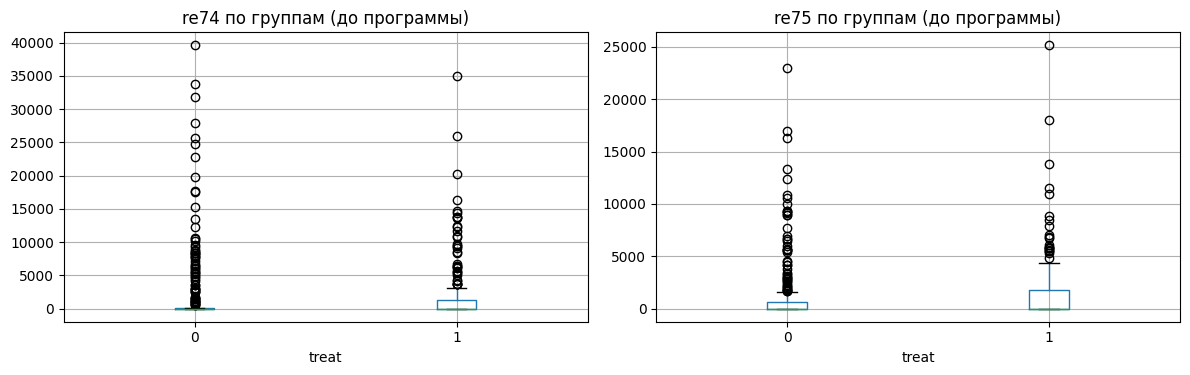

Доля нулевого дохода в re74/re75 (не работали в этот год):
           re74      re75
treat                    
0      0.750000  0.684615
1      0.708108  0.600000


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col in zip(axes, ['re74', 're75']):
    df.boxplot(column=col, by='treat', ax=ax)
    ax.set_title(f'{col} по группам (до программы)')
    ax.set_xlabel('treat')
plt.suptitle('')
plt.tight_layout()
plt.show()

print('Доля нулевого дохода в re74/re75 (не работали в этот год):')
print(df.groupby('treat')[['re74','re75']].apply(lambda x: (x==0).mean()))

**Важное наблюдение для дальнейшей методологии:** доход (`re74`, `re75`,
`re78`) имеет массу нулей — это не выбросы и не пропуски, это люди без
занятости в соответствующем году. Распределение дохода поэтому не
нормальное, а с точечной массой в нуле и длинным правым хвостом.

## 4. Baseline: истинный ATE из RCT

In [ ]:
treat_y = df.loc[df.treat==1, 're78']
control_y = df.loc[df.treat==0, 're78']

ate_naive = treat_y.mean() - control_y.mean()
ttest = stats.ttest_ind(treat_y, control_y)
se_naive = ate_naive / ttest.statistic
ci_naive = stats.t.interval(0.95, df=len(treat_y)+len(control_y)-2, loc=ate_naive, scale=se_naive)

print(f'Средний re78, treat:   {treat_y.mean():,.0f}')
print(f'Средний re78, control: {control_y.mean():,.0f}')
print(f'ATE (diff-in-means):   {ate_naive:,.0f}')
print(f'SE: {se_naive:,.0f}')
print(f'95% CI: [{ci_naive[0]:,.0f}, {ci_naive[1]:,.0f}]')
print(f't-statistic: {ttest.statistic:.3f}, p-value: {ttest.pvalue:.4f}')

Средний re78, treat:   6,349
Средний re78, control: 4,555
ATE (diff-in-means):   1,794
SE: 633
95% CI: [551, 3,038]
t-statistic: 2.835, p-value: 0.0048


**Сохраняем эталон как артефакт.** Чтобы следующие части проекта (наблюдательный
датасет, PSM, DML) не тащили это число как текстовую константу и не пересчитывали
RCT заново, фиксируем его в `benchmark.json` рядом с ноутбуками — все последующие
части будут загружать его оттуда.

In [ ]:
import json

benchmark = {
    "ate": float(ate_naive),
    "se": float(se_naive),
    "ci_low": float(ci_naive[0]),
    "ci_high": float(ci_naive[1]),
    "p_value": float(ttest.pvalue),
    "n_treat": int(len(treat_y)),
    "n_control": int(len(control_y)),
    "method": "diff-in-means (pooled-variance t-test), RCT nsw_mixtape",
    "source_notebook": "01_baseline_rct.ipynb"
}

with open("benchmark.json", "w") as f:
    json.dump(benchmark, f, indent=2)

benchmark

{'ate': 1794.34326171875,
 'se': 632.8533801214705,
 'ci_low': 550.575369960261,
 'ci_high': 3038.111153477239,
 'p_value': 0.004787508750949327,
 'n_treat': 185,
 'n_control': 260,
 'method': 'diff-in-means (pooled-variance t-test), RCT nsw_mixtape',
 'source_notebook': '01_baseline_rct.ipynb'}

## 5. Итог этой части - что фиксируем как ground truth

**ATE (diff-in-means): 1,794 (95% CI: [551, 3,038], SE: 633, p=0.005)**

Эффект участия в программе NSW статистически значим и составляет прирост
примерно 1,794 к годовому доходу (`re78`) участника. Поскольку данные -
результат честной рандомизации, эта оценка не требует никаких
дополнительных допущений о ненаблюдаемых факторах и не нуждается в
поправках на ковариаты - разница средних между группами сама по себе и есть
причинный эффект.

**Что фиксируем как эталон для следующих частей проекта** (PSM, matching,
DML на наблюдательных данных NSW + CPS/PSID control):

> **Основной бенчмарк: 1,794 (95% CI: [551, 3,038], SE: 633)**

Все последующие наблюдательные оценки будут сравниваться с этим числом -
чем ближе оценка метода к нему, тем лучше метод справился с
восстановлением причинного эффекта без рандомизации.

## Что дальше в этом проекте

1. **Наблюдательный датасет** - NSW treatment + CPS/PSID control (тот же
   пакет `causaldata`), наивная оценка на нём и величина смещения
   относительно эталона выше
2. **PSM / Matching** - коррекция смещения, balance-таблица до/после,
   overlap/common support
3. **DML** - та же задача через более гибкий метод, сравнение с matching
4. **Валидация** - placebo-тест, чувствительность к набору confounders
5. **DiD на отдельном классическом кейсе** (Card & Krueger / Prop 99)